<a href="https://colab.research.google.com/github/AnnisB/AnnisB/blob/main/TP_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1_Unsupervised

## Importing libraries

In [ ]:
# Datasets
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# Clustering, density estimation
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score, adjusted_rand_score
from sklearn.mixture import GaussianMixture

# Dimensionality reduction
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import TSNE

## 1. Datasets

### 1.3 Loading the data

#### Q1.

In [ ]:
# Temperature dataset
temper = np.load("temper.npz")

data1 = temper["data"]
villes = temper["villes"]
varname = temper["varname"]

# Only the 12 monthly temperatures for ml
x1 = data1[:, :12]

# Keep geographical information separately for later interpretation
latitude = data1[:, 12]
longitude = data1[:, 13]

# Digits dataset
digits = np.load("digits.npz")

x2 = digits["x"]
xt2 = digits["xt"]
y2 = digits["y"]
yt2 = digits["yt"]

# Scale pixel values to [0, 1]
x2 = x2 / 255.0
xt2 = xt2 / 255.0

In [ ]:
print("x1:", x1.shape)
print("x2:", x2.shape)
print("xt2:", xt2.shape)
print("y2:", y2.shape)
print("yt2:", yt2.shape)

x1: (15, 12)
x2: (3000, 784)
xt2: (1500, 784)
y2: (3000, 1)
yt2: (1500, 1)


#### Q2.

In [ ]:
print("Temperature dataset")
print("Shape:", x1.shape)
print("Minimum:", np.min(x1))
print("Maximum:", np.max(x1))
print("Mean:", np.mean(x1))
print("Standard deviation:", np.std(x1))

Temperature dataset
Shape: (15, 12)
Minimum: 0.4
Maximum: 23.3
Mean: 11.813888888888888
Standard deviation: 5.909171439276866


In [ ]:
print("Standard deviation for each month:")
print(np.std(x1, axis=0))

Standard deviation for each month:
[1.93923238 1.80505463 1.47723465 1.36684552 1.45357796 1.73269219
 2.0567504  1.94376496 1.78544735 1.76793665 1.74259066 1.89204181]


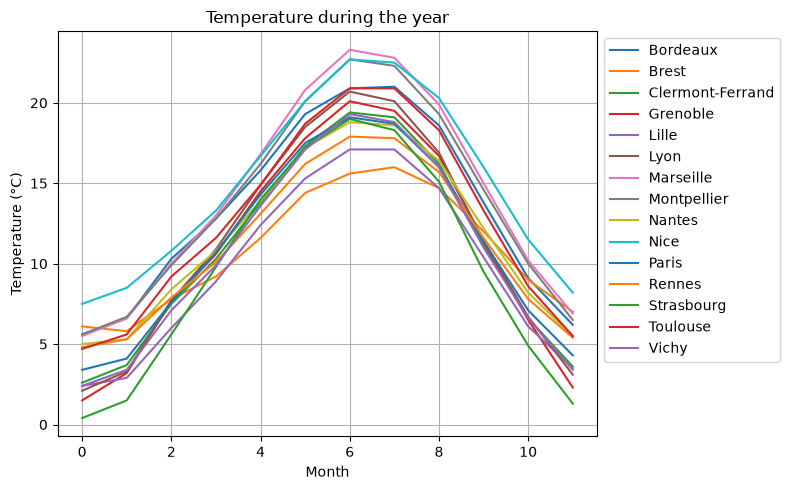

In [ ]:
months = np.arange(12)

plt.figure(figsize=(8,5))

for i in range(x1.shape[0]):
    plt.plot(months, x1[i], label=villes[i])

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Temperature during the year")
plt.xticks(np.arange(0, 12, 2))
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

We can see a clear seasonal pattern shared by all the cities. \
The lowest temperatures in winter and the highest temperatures around 6-7 months. \
We notice differences in overall temperatures levels between cities, also in seasonal amplitude. \
These differences may help distinguish cities during clustering.

In [ ]:
print("Digits dataset")
print("Shape:", x2.shape)
print("Minimum:", np.min(x2))
print("Maximum:", np.min(x2))
print("Mean:", np.mean(x2))
print("Standard deviation:", np.std(x2))

Digits dataset
Shape: (3000, 784)
Minimum: 0.0
Maximum: 0.0
Mean: 0.11479026110444175
Standard deviation: 0.29203890581562364


In [ ]:
classes, counts = np.unique(y2, return_counts=True)

print("Classes:", classes)
print("Number of samples per class:", counts)

Classes: [1 7 8]
Number of samples per class: [1000 1000 1000]


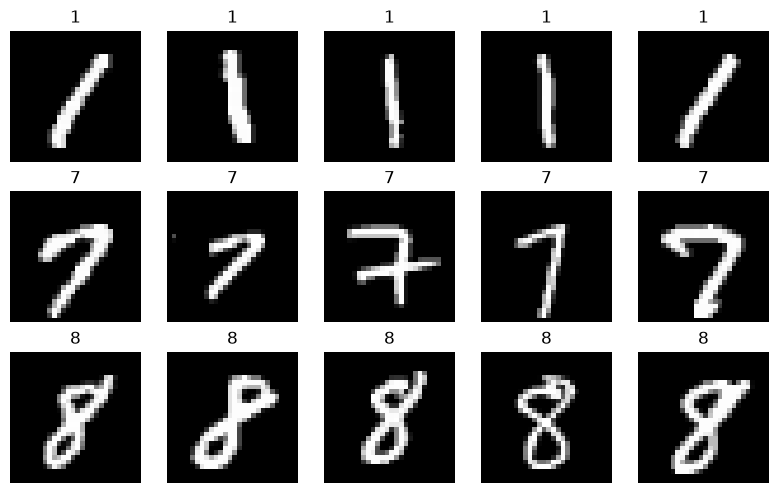

In [ ]:
classes = np.unique(y2)
n_examples = 5

plt.figure(figsize=(8,5))

plot_idx = 1

for digit in classes:
    indices = np.where(y2 == digit)[0][:n_examples]

    for idx in indices:
        plt.subplot(len(classes), n_examples, plot_idx)

        plt.imshow(x2[idx].reshape(28, 28), cmap="gray")
        plt.title(str(digit))
        plt.axis("off")

        plot_idx += 1

plt.tight_layout()
plt.show()

Classes are visually distinguishable. \
We notice significant intra-class variability in tilt, thickness, position, shape, and stroke style. \
Then, samples belonging to the same class may be different in pixel space, which can make unsupervised clustering more difficult.

#### Q3.

In [ ]:
mean_temp = np.mean(x1, axis=0)

print(mean_temp)
print(mean_temp.shape)

[ 3.97333333  4.83333333  8.23333333 10.98       14.43333333 17.83333333
 19.83333333 19.56666667 16.98666667 12.32        7.92666667  4.84666667]
(12,)


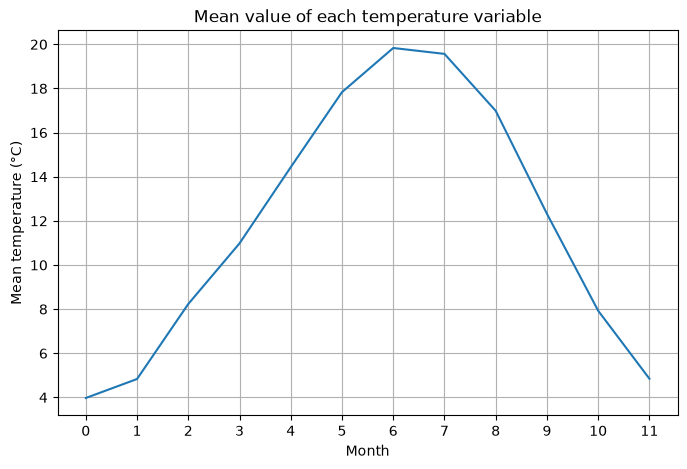

In [ ]:
months = np.arange(12)

plt.figure(figsize=(8, 5))

plt.plot(months, mean_temp)

plt.xlabel("Month")
plt.ylabel("Mean temperature (°C)")
plt.title("Mean value of each temperature variable")
plt.xticks(months)
plt.grid()

plt.show()

We see a clear and smooth seasonal trend. \
Temperatures increases from winter to summer, peaks around months 6-7, then decreases. \
It captures the common seasonal behavior between cities.

In [ ]:
mean_digits = np.mean(x2, axis=0)
print(mean_digits.shape)

(784,)


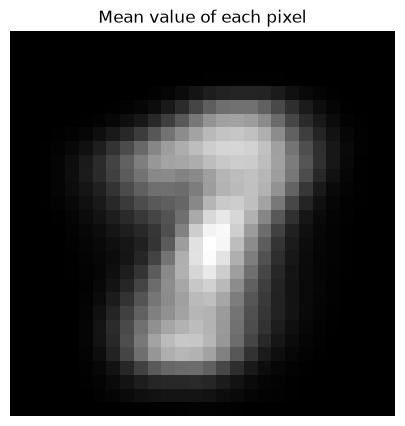

In [ ]:
plt.figure(figsize=(8, 5))

plt.imshow(mean_digits.reshape(28, 28), cmap="gray")
plt.title("Mean value of each pixel")
plt.axis("off")

plt.show()

The mean image is blurred and doesnt represent one specific digit. \
It comes from differences between the three classes and variations in handwriting. \
It summarizes overall spacial sructure but losses specificity.

#### Q4. (Bonus)

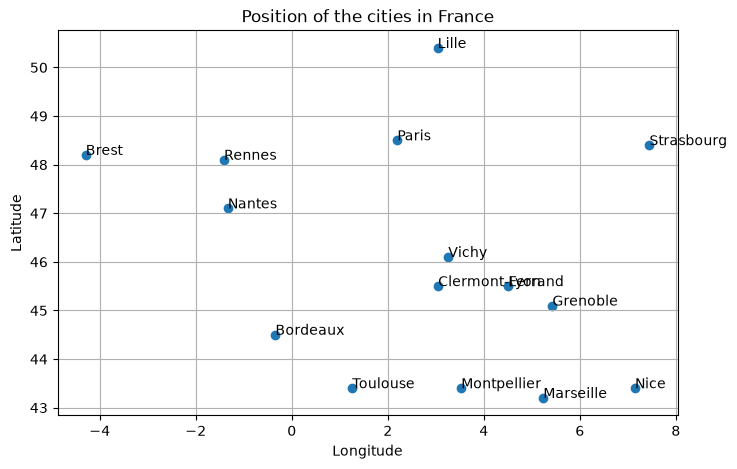

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(longitude, latitude)

for i in range(len(villes)):
    plt.text(longitude[i], latitude[i], villes[i])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Position of the cities in France")
plt.grid()

plt.show()

It shows cities spread across different geographical regions of France. \
The map can be used to check whether clusters obtained only from temeperatures features also exhibit geographical structure.

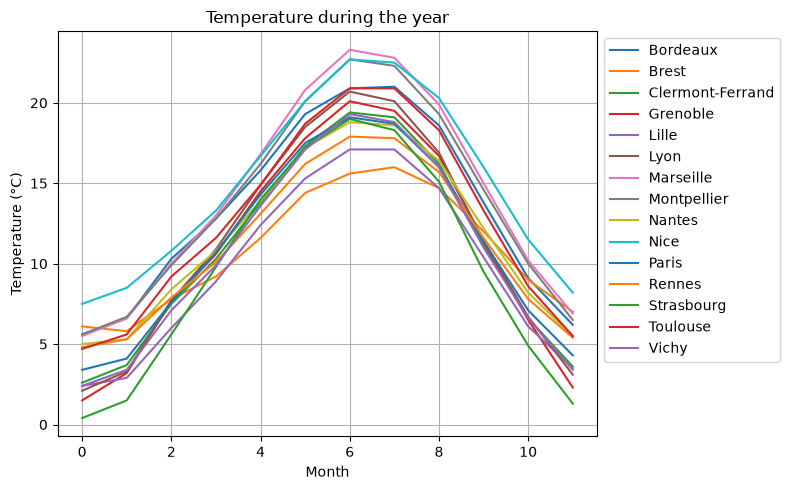

In [ ]:
months = np.arange(12)

plt.figure(figsize=(8, 5))

for i in range(x1.shape[0]):
    plt.plot(months, x1[i], label=villes[i])

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Temperature during the year")
plt.xticks(np.arange(0, 12, 2))
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()

plt.show()

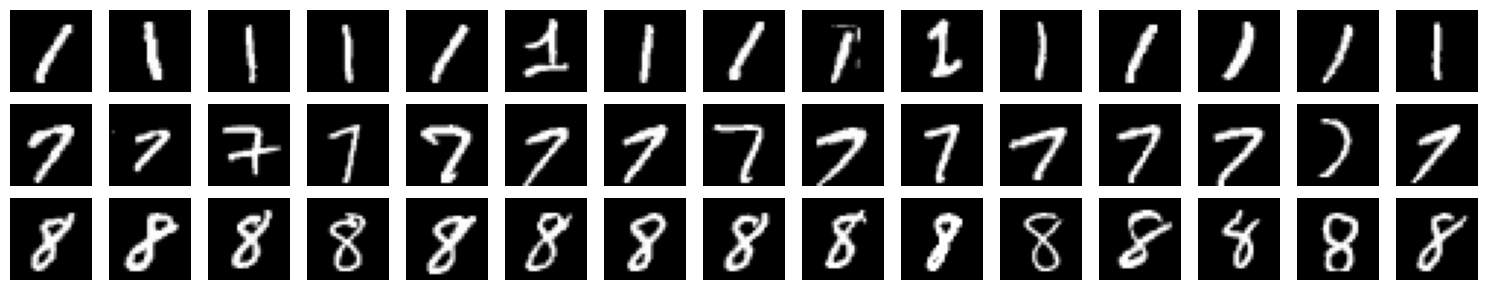

In [ ]:
classes = np.unique(y2)
n_examples = 15

plt.figure(figsize=(15, 3))

plot_idx = 1

for digit in classes:
    indices = np.where(y2 == digit)[0][:n_examples]

    for idx in indices:
        plt.subplot(len(classes), n_examples, plot_idx)

        plt.imshow(x2[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")

        plot_idx += 1

plt.tight_layout()
plt.show()

## 2. Clustering

### 2.1 For both datasets

#### Q1.

In [ ]:
kmeans_temp = KMeans(n_clusters=3, random_state=0)

labels_temp = kmeans_temp.fit_predict(x1)
centroids_temp = kmeans_temp.cluster_centers_

print("Temperature labels:")
print(labels_temp)

print("Labels shape:", labels_temp.shape)
print("Centroids shape:", centroids_temp.shape)

Temperature labels:
[1 0 2 2 2 2 1 1 0 1 2 0 2 1 2]
Labels shape: (15,)
Centroids shape: (3, 12)


C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
kmeans_digits = KMeans(n_clusters=3, random_state=0)

labels_digits = kmeans_digits.fit_predict(x2)
centroids_digits = kmeans_digits.cluster_centers_

print("Digits labels:")
print(labels_digits)

print("Label shape:", labels_digits.shape)
print("Centroids shape:", centroids_digits.shape)

Digits labels:
[1 1 1 ... 2 2 2]
Label shape: (3000,)
Centroids shape: (3, 784)


#### Q2.

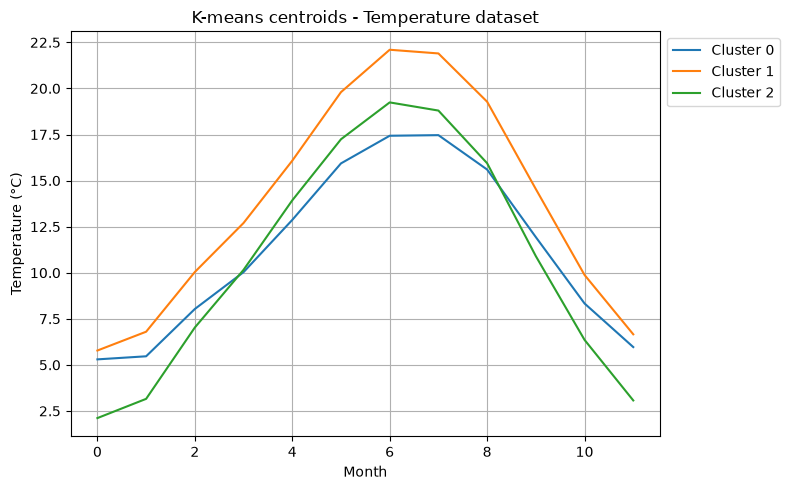

In [ ]:
months = np.arange(12)

plt.figure(figsize=(8, 5))

for k in range(3):
    plt.plot(months, centroids_temp[k], label=f"Cluster {k}")

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("K-means centroids - Temperature dataset")
plt.xticks(np.arange(0, 12, 2))
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()

plt.show()

All three centroids preserve the same general seasonal pattern. \
Cluster 1 is the warmest cluster overall. \
What is intresting is that Cluster 0 and Cluster 2 switch positions with seasonal transition. \
Also, Cluster 2 has bigger temperatures amplitude than Cluster 0. \
It means that K-means seems to separate cities according to both overall temperature level and seasonal amplitude. \
The centroids may correspond to different climatic/geographical profiles, but this must be checked using city names and geographical plot.

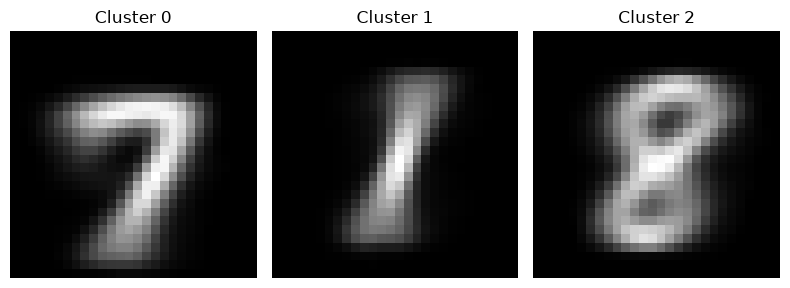

In [ ]:
plt.figure(figsize=(8, 5))

for k in range(3):
    plt.subplot(1, 3, k + 1)

    plt.imshow(centroids_digits[k].reshape(28, 28), cmap="gray")

    plt.title(f"Cluster {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

The three centroids are clearly recognizable as 7, 1 and 8. \
Therefore, K-means with K=3 seems to recover classes reasonably well. \
However, centroids are blurred because it shows average images as we saw earlier, which reflects intra-class variability. \
It doesnt prove yet that every individual sample is correctly clustered.

#### Q3.

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


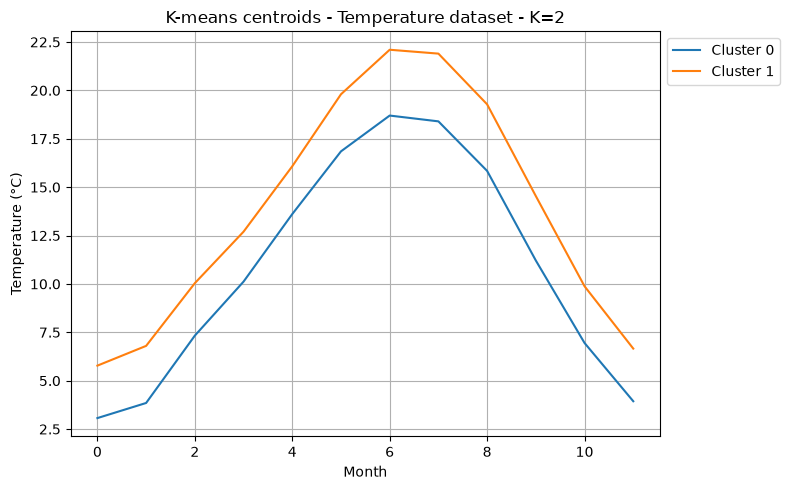

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


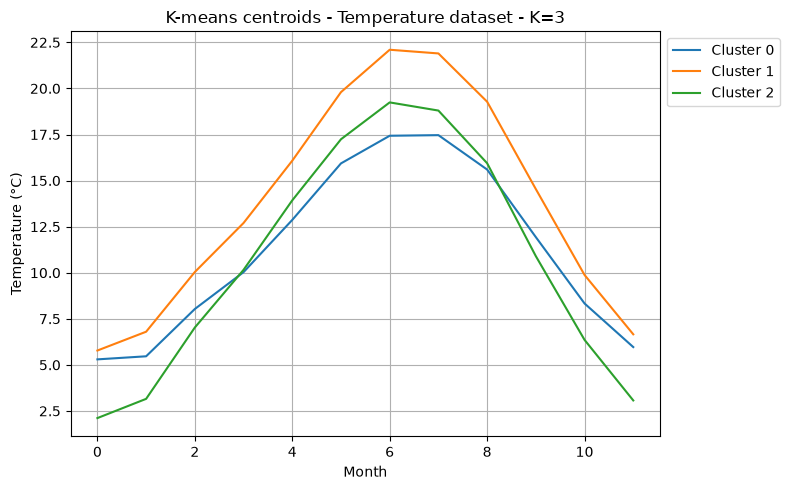

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


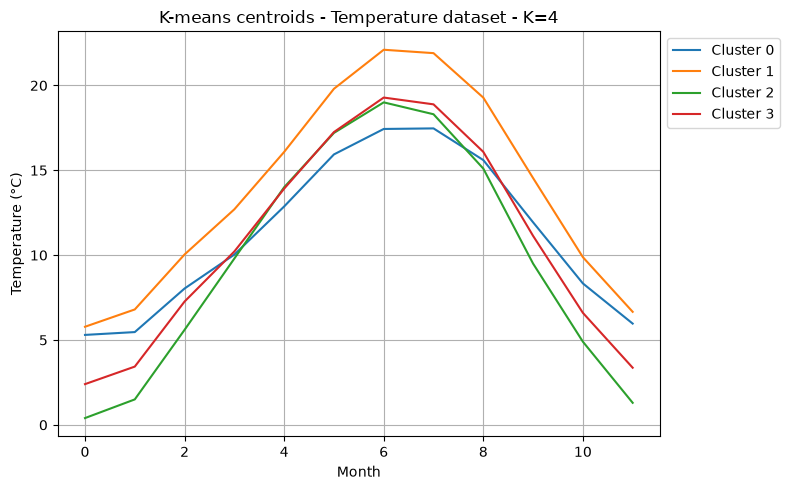

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


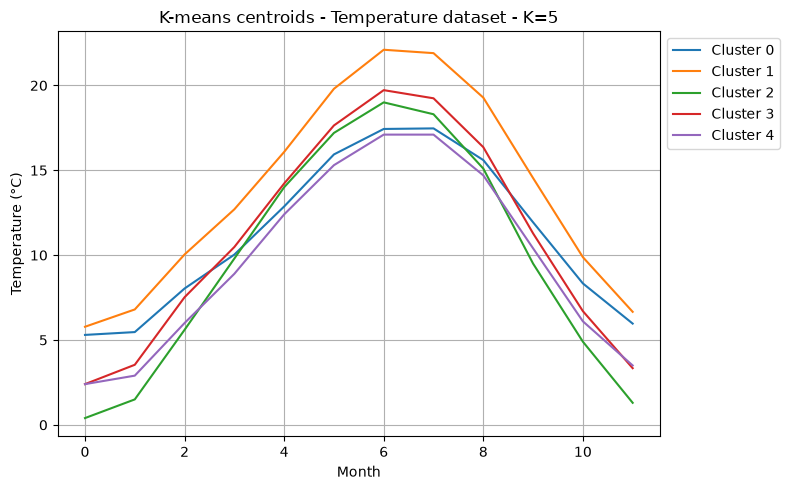

In [ ]:
K_values_temp = [2, 3, 4, 5]
months = np.arange(12)

for K in K_values_temp:
    model = KMeans(n_clusters=K, random_state=0)

    labels = model.fit_predict(x1)
    centroids = model.cluster_centers_

    plt.figure(figsize=(8, 5))

    for k in range(K):
        plt.plot(months, centroids[k], label=f"Cluster {k}")

    plt.xlabel("Month")
    plt.ylabel("Temperature (°C)")
    plt.title(f"K-means centroids - Temperature dataset - K={K}")
    plt.xticks(np.arange(0, 12, 2))
    plt.grid()
    plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
    plt.tight_layout()

    plt.show()

K=2 : It mainly separates a warmer profile from a colder profile. \
K=3 : A third meaningful profile appears: a warm profile, a profile with milder winters and cooler summers, a profile with colder winters and relatively warm summers, hence a larger seasonal amplitude. It captures more information without being too complicated. \
K>=4 : Additional centroids mainly subdivides profiles and start to look oversegmented.

K=3 seems like the best compromise between simplicity and meaningfulness.

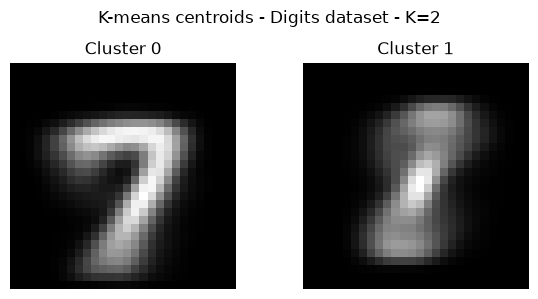

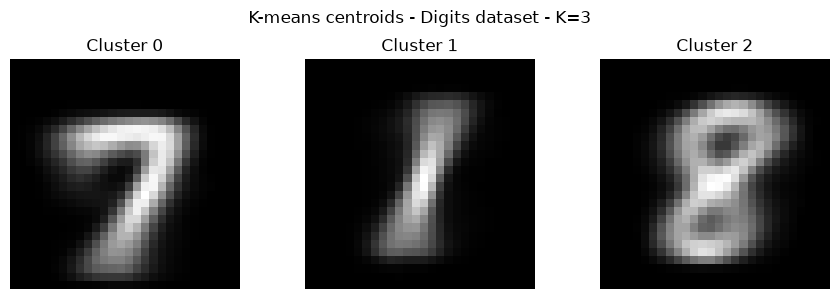

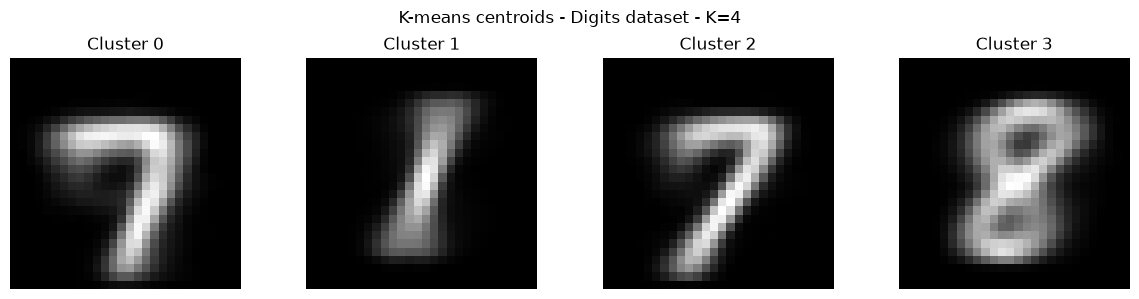

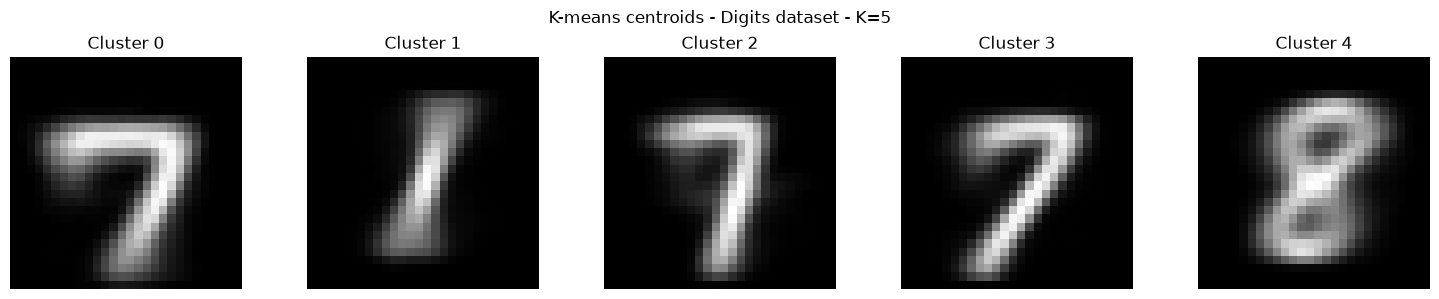

In [ ]:
K_values_digits = [2, 3, 4, 5]
months = np.arange(12)

for K in K_values_digits:
    model = KMeans(n_clusters=K, random_state=0)

    labels = model.fit_predict(x2)
    centroids = model.cluster_centers_

    plt.figure(figsize=(3 * K, 3))

    for k in range(K):
        plt.subplot(1, K, k + 1)
        plt.imshow(centroids[k].reshape(28, 28), cmap="gray")
        plt.title(f"Cluster {k}")
        plt.axis("off")

    plt.suptitle(f"K-means centroids - Digits dataset - K={K}")
    plt.tight_layout()
    plt.show()

K=2 : One centroid clearly represents 7, and the other one looks like a mix between 1 and 8. K=2 is too small. \
K=3 : The three centroids clearly resemble 1, 7 and 8. It suggests K=3 is a well match to the structure of the dataset. \
K>=4 : Extra clusters correspond to handwriting styles. It clusters intra-class variability.

If we want to recover the three digit classes, K=3 is the most natural choice. \
If we want to model intra-class variability, we can choose K>3.

### 2.2 Temperature dataset

#### Q1.

In [ ]:
for k in range(3):
    print(f"Cluster {k}:")
    print(villes[labels_temp == k])
    print()

Cluster 0:
['Brest' 'Nantes' 'Rennes']

Cluster 1:
['Bordeaux' 'Marseille' 'Montpellier' 'Nice' 'Toulouse']

Cluster 2:
['Clermont-Ferrand' 'Grenoble' 'Lille' 'Lyon' 'Paris' 'Strasbourg' 'Vichy']



The clustering makes sens and is consistent with the centroids previously observed : \
Cluster 0 : Western France, oceanic climate. It matches the centroid with relatively mild winters and cooler summers. \
Cluster 1 : Southern France, warmer temperatures. It matches the warmer centroid.    \
Cluster 2 : Inland, northern, eastern France. It matches the centroid with colder winters and stronger seasonal variations. \

We didn't use latitude/longitude information for clustering but we can retrieve indirectly geographical information from temperatures data.

#### Q2.

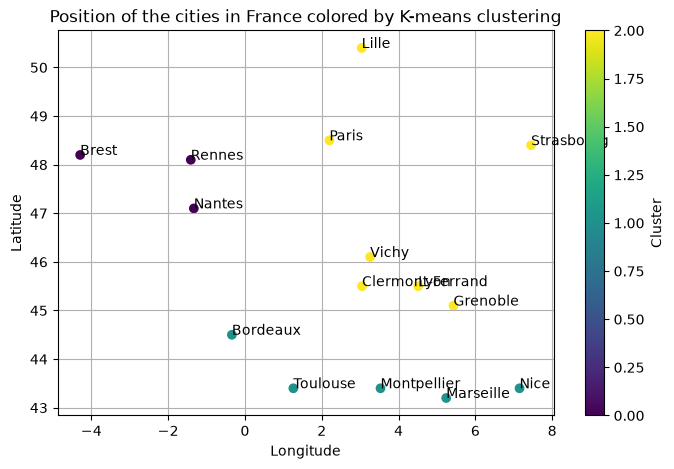

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(longitude, latitude, c=labels_temp)

for i in range(len(villes)):
    plt.text(longitude[i], latitude[i], villes[i])

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Position of the cities in France colored by K-means clustering")
plt.colorbar(label="Cluster")
plt.grid()

plt.show()

As we said, the clusters show a clear geographical structure even tough latitude/longituded were not used. \
It means that cities that are geographically close often have similar annual temperatures profiles.

### 2.3 Digits dataset

#### Q1.

As we said earlier, the centroids resemble the digits 1, 7 and 8. \
However, they look more blurred than the actual samples. \
Indeed, a centroid is the arithmetic mean of all samples assigned to a cluster, so it carries intra-class variability. \
Unlike medoid, centroid is an average image that doesnt need to correspond to any actual image.

#### Q2.

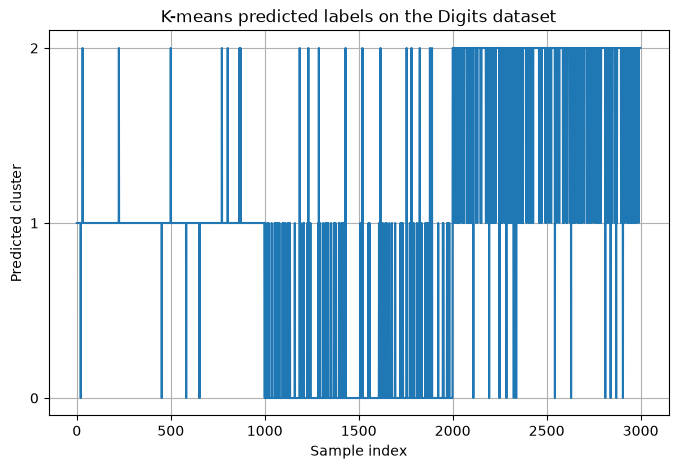

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(labels_digits)

plt.xlabel("Sample index")
plt.ylabel("Predicted cluster")
plt.title("K-means predicted labels on the Digits dataset")
plt.yticks([0, 1, 2])
plt.grid()

plt.show()

The predicted-label signal is approximately piecewise constant, but there are still some mistakes. \
Cluster 1 refers to digit 1, Cluster 0 refers to digit 7 and Cluster 2 refers to digit 8. \
We can see barely see that digits 7 and 8 can sometimes be confused with another digit because of handwriting style for example.

Here, K-means clustering captures the overall structure but is not perfect. \
We need to compute scores to analyze precisely the situation.

#### Q3.

In [ ]:
rand = rand_score(y2.ravel(), labels_digits)
adjusted_rand = adjusted_rand_score(y2.ravel(), labels_digits)

print("Rand score:", rand)
print("Adjusted Rand score:", adjusted_rand)

Rand score: 0.8839530954762699
Adjusted Rand score: 0.7405571626609085


The rand score is high which indicates a strong agreement between K-means clustering and true classes. \
The adjusted rand score is lower because it corrects for agreements that could occur by chance.

#### Q4.

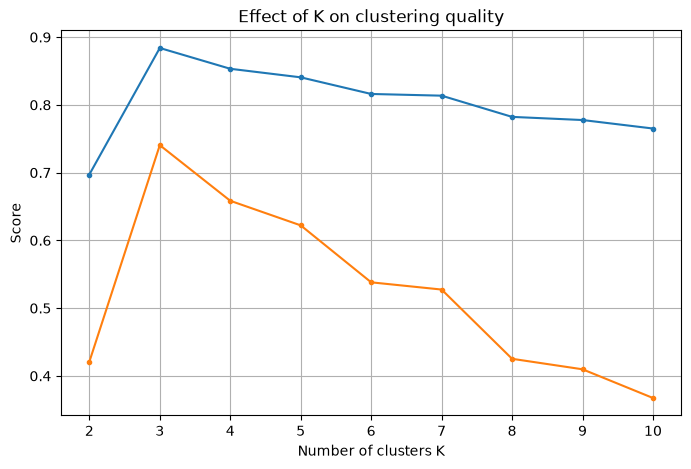

In [ ]:
K_values = range(2, 11)

rand_scores = []
adjusted_rand_scores = []

for K in K_values:
    model = KMeans(n_clusters=K, random_state=0)
    labels = model.fit_predict(x2)

    rand_scores.append(rand_score(y2.ravel(), labels))
    adjusted_rand_scores.append(adjusted_rand_score(y2.ravel(), labels))

plt.figure(figsize=(8,5))

plt.plot(K_values, rand_scores, label="Rand score", marker="o", markersize=3)
plt.plot(K_values, adjusted_rand_scores, label="Adjusted Rand score", marker="o", markersize=3)

plt.xlabel("Number of clusters K")
plt.ylabel("Score")
plt.title("Effect of K on clustering quality")
plt.xticks(list(K_values))
plt.grid()

plt.show()

K-means clustering with K=3 leads to the best score in both rand_score and adjusted_rand_score. \
This is consistent with the dataset structure containing three classes. \
Taking K=2 is too small to represent three classes and taking K>3 can split true classes depending on handwriting styles for example.

## 3. Density estimation

### 3.1 For both datasets

#### Q1.

In [ ]:
gmm_temp = GaussianMixture(n_components=2, covariance_type="diag", random_state=0)

gmm_temp.fit(x1)

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'diag'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [ ]:
print("Means shape:", gmm_temp.means_.shape)
print("Covariances shape:", gmm_temp.covariances_.shape)
print("Weights:", gmm_temp.weights_.shape)

Means shape: (2, 12)
Covariances shape: (2, 12)
Weights: (2,)


In [ ]:
gmm_digits = GaussianMixture(n_components=3, covariance_type="diag", random_state=0)

gmm_digits.fit(x2)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'diag'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [ ]:
print("Means shape:", gmm_digits.means_.shape)
print("Covariances shape:", gmm_digits.covariances_.shape)
print("Weights:", gmm_digits.weights_.shape)

Means shape: (3, 784)
Covariances shape: (3, 784)
Weights: (3,)


#### Q2.

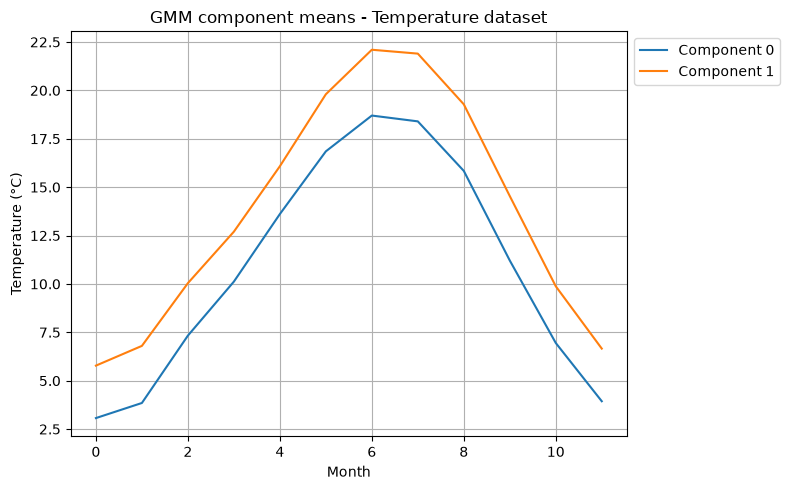

In [ ]:
months = np.arange(12)

plt.figure(figsize=(8,5))

for k in range(gmm_temp.n_components):
    plt.plot(months, gmm_temp.means_[k], label=f"Component {k}")

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("GMM component means - Temperature dataset")
plt.xticks(np.arange(0, 12, 2))
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

Both Gaussian components preserve the same overall seasonal pattern (a warmer profile and a colder profile).

The two GMM means are very similar to the two K-means centroids previously obtained with K=2.

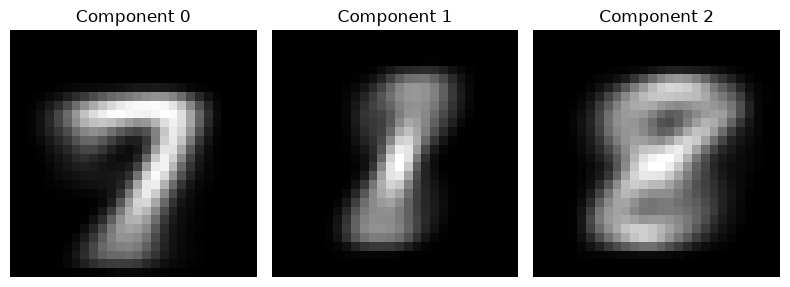

In [ ]:
plt.figure(figsize=(8, 5))

for k in range(gmm_digits.n_components):
    plt.subplot(1, 3, k + 1)

    plt.imshow(gmm_digits.means_[k].reshape(28, 28), cmap="gray")

    plt.title(f"Component {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

The three component means are clearly recognizable as approximately 7, 1, and 8 but still blurred as they still represent averages of many handwriting styles.

They are qualitatively very similar to the K-means centroids obtained for K=3.

#### Q3.

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


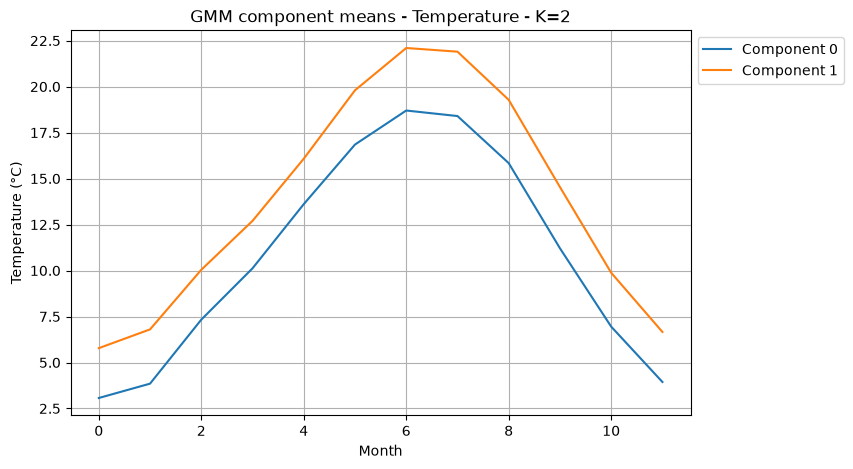

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


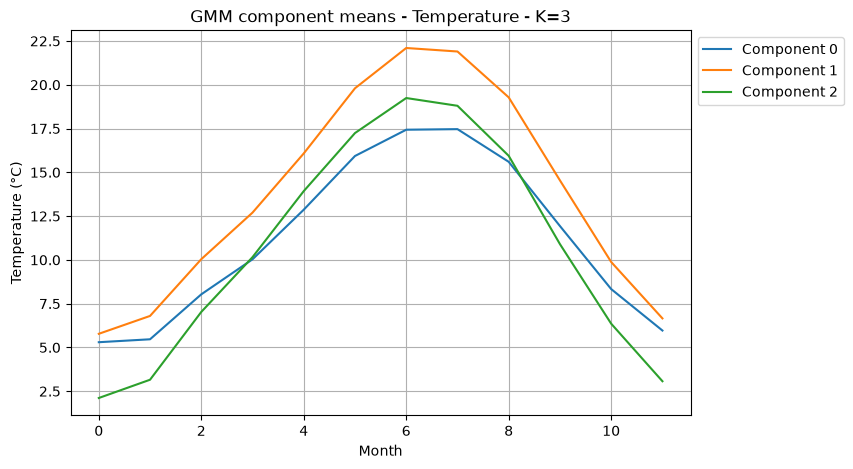

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


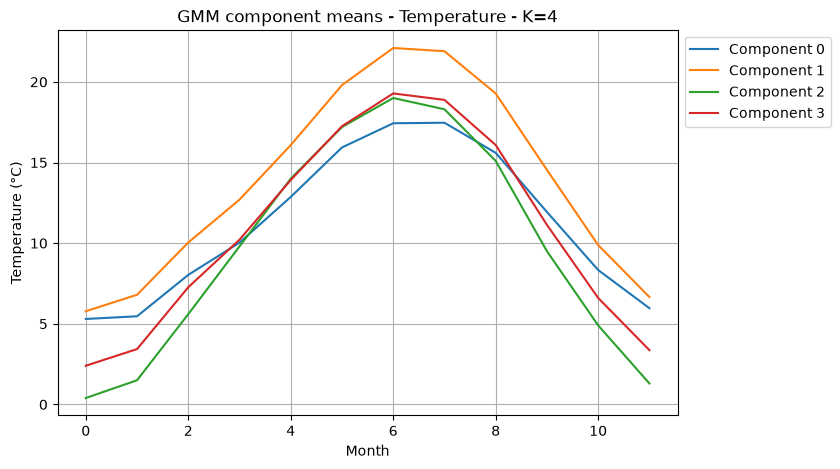

C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


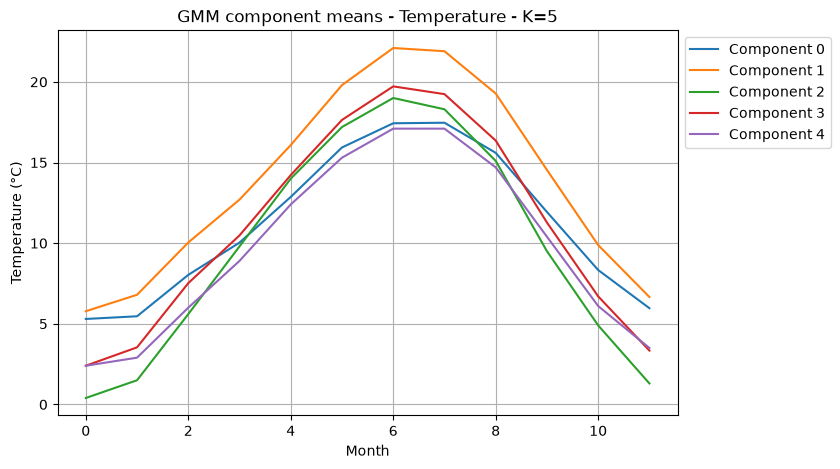

In [ ]:
K_values_temp = [2, 3, 4, 5]

months = np.arange(12)

for K in K_values_temp:
    model = GaussianMixture(n_components=K, covariance_type="diag", random_state=0)

    model.fit(x1)

    plt.figure(figsize=(8, 5))

    for k in range(K):
        plt.plot(months, model.means_[k], label=f"Component {k}")

    plt.xlabel("Month")
    plt.ylabel("Temperature (°C)")
    plt.title(f"GMM component means - Temperature - K={K}")
    plt.xticks(np.arange(0, 12, 2))
    plt.grid()
    plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
    plt.show()

Again, results look very similar to K-means.

K=2 gives a simple warm/cold separation, while K=3 captures an additional meaningful seasonal profile. \
For K=4 and K=5, several component means become relatively similar, suggesting over-segmentation of a dataset containing only 15 samples.

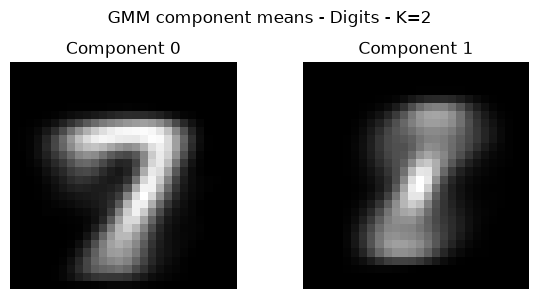

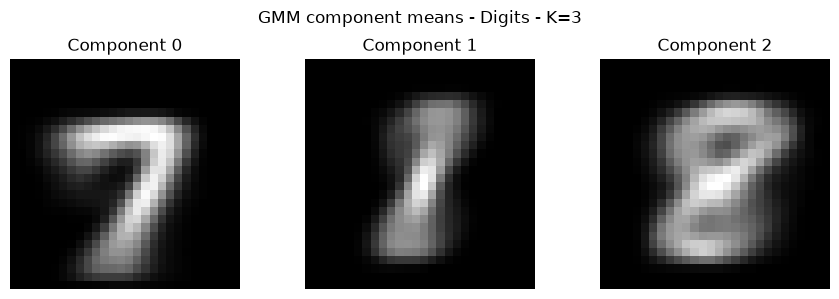

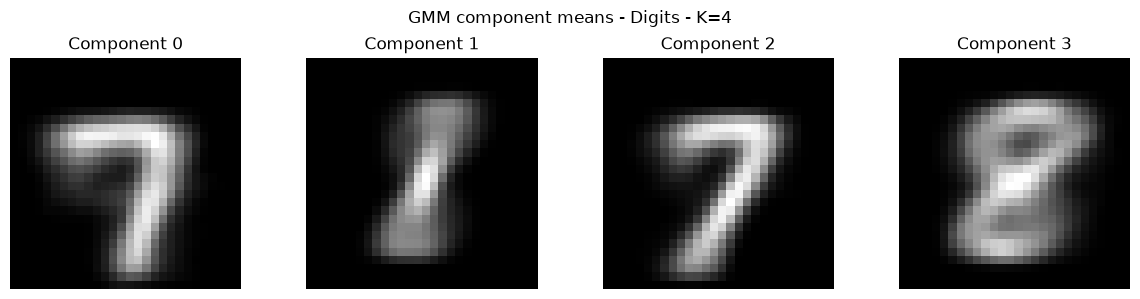

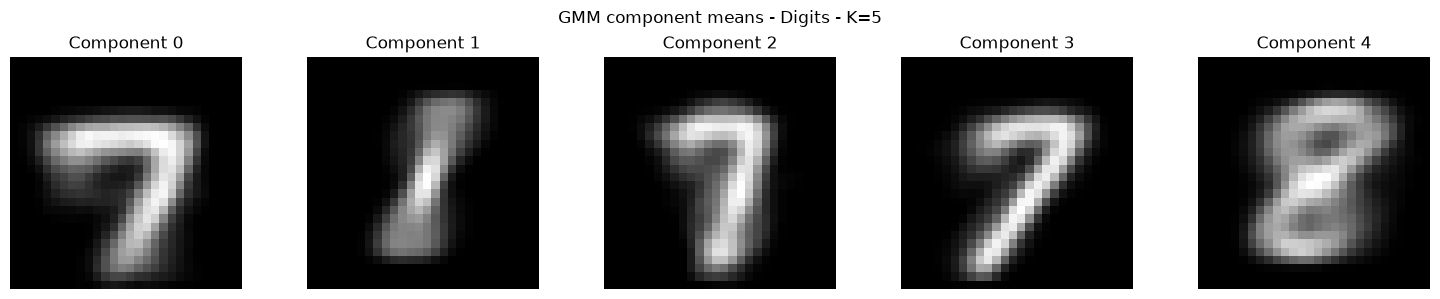

In [ ]:
K_values_digits = [2, 3, 4, 5]

for K in K_values_digits:
    model = GaussianMixture(n_components=K, covariance_type="diag", random_state=0)

    model.fit(x2)

    plt.figure(figsize=(3 * K, 3))

    for k in range(K):
        plt.subplot(1, K, k + 1)
        plt.imshow(model.means_[k].reshape(28, 28), cmap="gray")
        plt.title(f"Component {k}")
        plt.axis("off")

    plt.suptitle(f"GMM component means - Digits - K={K}")
    plt.tight_layout()
    plt.show()

K=3 naturally recovers component means resembling the three true classes 1, 7, 8. \
For K>3, the additional Gaussian components mainly model intra-class variability, especially different handwriting styles of the digit 7.

K=3 is a natural choice if the objective is to recover the three semantic digit classes.

In [ ]:
cov_types = ["spherical", "diag", "tied", "full"]

for cov_type in cov_types:
    model = GaussianMixture(n_components=2, covariance_type=cov_type, random_state=0)

    model.fit(x1)

    print(cov_type, "converged =", model.converged_)
    print("covariance shape =", model.covariances_.shape)
    print()

spherical converged = True
covariance shape = (2,)

diag converged = True
covariance shape = (2, 12)

tied converged = True
covariance shape = (12, 12)

full converged = True
covariance shape = (2, 12, 12)



C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Annis\miniconda3\envs\tp_ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning:

In [ ]:
cov_types_digits = ["spherical", "diag"]

for cov_type in cov_types_digits:
    model = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=0)

    model.fit(x2)

    print(cov_type, "converged =", model.converged_)
    print("covariance shape =", model.covariances_.shape)
    print()

spherical converged = True
covariance shape = (3,)

diag converged = True
covariance shape = (3, 784)



Convergence does not mean reliable statistical estimation. \
Estimation quality depends on both the number of samples and the number of parameters to estimate.

spherical is very restrictive but easy to estimate \
diag allows a different variance for every feature while keeping the number of parameters manageable \
full can represent feature correlations but requires far too many parameters, especially for the digits dataset \
tied reduces the number of parameters by sharing one full covariance between all components

#### Q4.

In [ ]:
scores_temp = gmm_temp.score_samples(x1)
idx_temp = np.argsort(scores_temp)

print("Smallest log-probabilities:")

for idx in idx_temp[:5]:
    print(villes[idx], scores_temp[idx])

Smallest log-probabilities:
Brest -30.66152561843063
Strasbourg -23.880568664860505
Toulouse -21.490788284364605
Lille -20.625418954633858
Nice -20.240133773781682


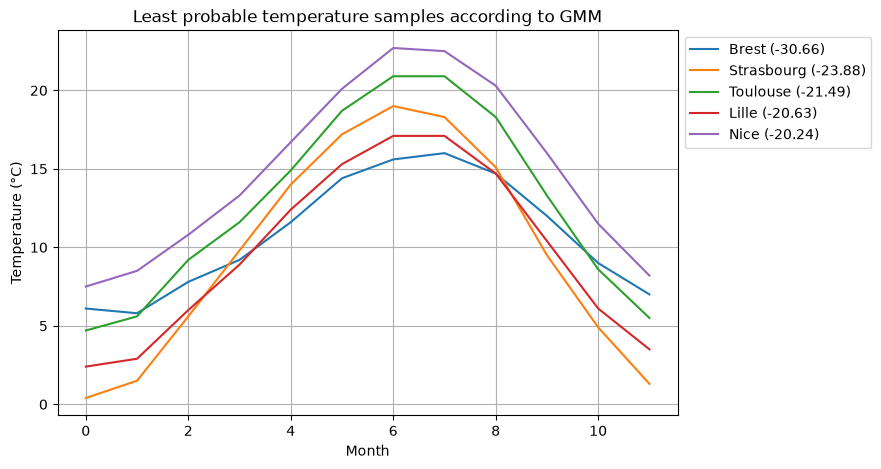

In [ ]:
n_outliers = 5
months = np.arange(12)

plt.figure(figsize=(8, 5))

for idx in idx_temp[:n_outliers]:
    plt.plot(months, x1[idx], label=f"{villes[idx]} ({scores_temp[idx]:.2f})")

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.title("Least probable temperature samples according to GMM")
plt.xticks(np.arange(0, 12, 2))
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

The least probable cities are Brest, Strasbourg, Toulouse, Lille and Nice. \
These cities correspond to relatively distinctive climatic profiles compared with the two Gaussian components learned by the model.

Since the model uses only K=2 Gaussian components, it is relatively coarse and cannot represent all climatic variations equally well.

Therefore, these cities receive lower likelihoods because their annual temperature profiles are less typical under the fitted mixture.

What is important is that outlier = sample poorly explained by the fitted model and not necessarily abnormal or erroneous sample.

In [ ]:
scores_digits = gmm_digits.score_samples(x2)
idx_digits = np.argsort(scores_digits)

print("Smallest log-probabilities:")
print(scores_digits[idx_digits[:5]])

Smallest log-probabilities:
[-10700.67504777  -7579.48892597  -4860.9043222   -2735.51306047
  -2668.000696  ]


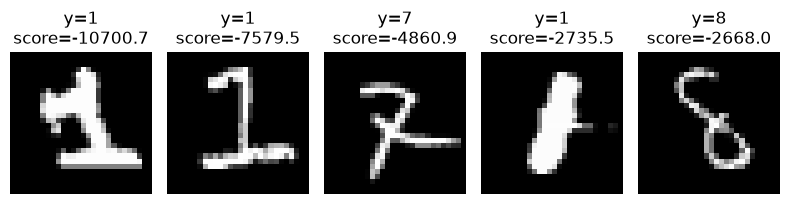

In [ ]:
n_outliers = 5

plt.figure(figsize=(8, 5))

for j, idx in enumerate(idx_digits[:n_outliers]):
    plt.subplot(1, 5, j + 1)

    plt.imshow(x2[idx].reshape(28, 28), cmap="gray")

    plt.title(f"y={y2.ravel()[idx]}\nscore={scores_digits[idx]:.1f}")

    plt.axis("off")

plt.tight_layout()
plt.show()

The least probable digits have unusual handwriting styles compared with the learned Gaussian component means. \
Several samples are strongly tilted, unusually thick, poorly centered, or have atypical strokes.

Some digits are visually ambiguous or significantly different from the average shape of their true class.

These unusual shapes therefore receive a low probability under the fitted GMM.

The result is consistent with the fact that the model represents each class using only one diagonal Gaussian component. \
A single Gaussian cannot capture all the handwriting variability present within one digit class.

#### Q5.

In [ ]:
labels_gmm = gmm_digits.predict(x2)

rand_gmm = rand_score(y2.ravel(), labels_gmm)
ari_gmm = adjusted_rand_score(y2.ravel(), labels_gmm)

print("GMM Rand score:", rand_gmm)
print("GMM Adjusted Rand score:", ari_gmm)

GMM Rand score: 0.7615936423252195
GMM Adjusted Rand score: 0.48064532426789625


In [ ]:
rand_kmeans = rand_score(y2.ravel(), labels_digits)
ari_kmeans = adjusted_rand_score(y2.ravel(), labels_digits)

print("K-means:")
print("Rand score:", rand_kmeans)
print("Adjusted Rand score:", ari_kmeans)

print("\nGMM:")
print("Rand score:", rand_gmm)
print("Adjusted Rand score:", ari_gmm)

K-means:
Rand score: 0.8839530954762699
Adjusted Rand score: 0.7405571626609085

GMM:
Rand score: 0.7615936423252195
Adjusted Rand score: 0.48064532426789625


K-means performs better than the GMM for clustering these digits.

Although the GMM is a more flexible probabilistic model, greater model complexity does not necessarily imply better clustering performance. \
The GMM is trained to maximize the data likelihood, not directly to recover the true semantic classes. \
With covariance_type="diag", each Gaussian component assumes conditional independence between pixels, which is a strong and unrealistic assumption for handwritten images. \
A single Gaussian component per digit may also be too simple to represent the large intra-class variability of handwriting.

K-means only relies on Euclidean distance to the centroids, and this simpler geometric criterion appears to match the structure of this particular dataset better.

#### Q6. (Bonus)

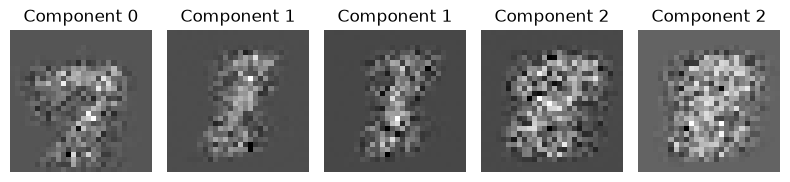

In [ ]:
generated_digits, generated_components = gmm_digits.sample(5)

plt.figure(figsize=(8, 5))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(generated_digits[i].reshape(28, 28), cmap="gray")
    plt.title(f"Component {generated_components[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

The generated samples roughly resemble the expected digits associated with their components. \
However, they are much noisier and less realistic than the real handwritten images.

Therefore, it is relatively easy to distinguish generated samples from real data.

The noisy appearance is partly explained by the use of a diagonal covariance matrix : pixels are generated independently conditionally on the component. \
This assumption ignores the strong spatial correlations between neighboring pixels that exist in real handwritten digits.

A single Gaussian component per class is also too simple to capture the complex variability of handwriting.

## 4. Dimensionality reduction

### 4.1 Dimensionality reduction

#### Q1.

In [ ]:
cov_temp = np.cov(x1.T)

print("Temperature covariance shape:", cov_temp.shape)

Temperature covariance shape: (12, 12)


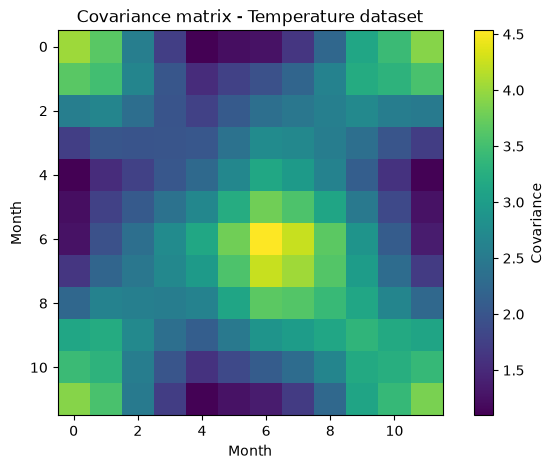

In [ ]:
plt.figure(figsize=(8, 5))

plt.imshow(cov_temp)
plt.colorbar(label="Covariance")

plt.xlabel("Month")
plt.ylabel("Month")
plt.title("Covariance matrix - Temperature dataset")

plt.show()

All covariance values are positive, meaning that cities that are relatively warm during one month also tend to be relatively warm during other months.

Neighboring months generally have strong covariance because temperatures evolve smoothly throughout the year.

The covariance is particularly high around the summer months, especially around months 6–7. \
Winter months also show relatively strong covariance with one another.

The dataset can potentially be represented in a much lower-dimensional space.

In [ ]:
cov_digits = np.cov(x2.T)

print("Digits covariance shape:", cov_digits.shape)

Digits covariance shape: (784, 784)


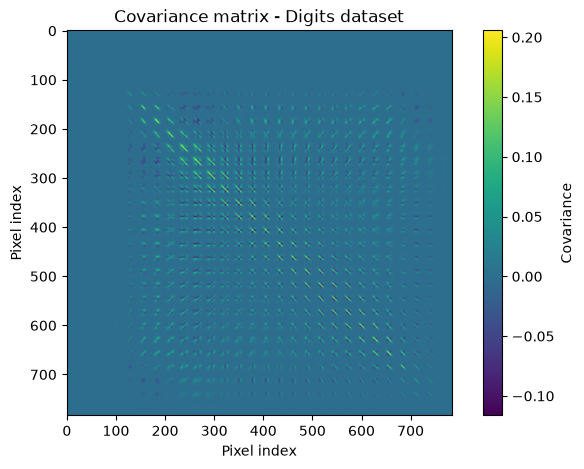

In [ ]:
plt.figure(figsize=(8, 5))

plt.imshow(cov_digits)
plt.colorbar(label="Covariance")

plt.xlabel("Pixel index")
plt.ylabel("Pixel index")
plt.title("Covariance matrix - Digits dataset")

plt.show()

The covariance matrix has a strong structured pattern concentrated in the central part of the image.

Strong covariance close to the diagonal is partly due to spatially neighboring pixels tending to be activated together when a stroke passes through them.

Some covariances are negative, meaning that certain pixels tend to be active when other pixels are inactive. \
This can result from differences between the shapes of digits 1, 7 and 8.

This again motivates dimensionality reduction : the 784 pixel values do not behave like 784 independent sources of information.

#### Q2.

In [ ]:
pca_temp = PCA(n_components=None)
pca_temp.fit(x1)

explained_temp = pca_temp.explained_variance_ratio_

print("\nVariance explained by the first 2 components:")
print(explained_temp[:2].sum())


Variance explained by the first 2 components:
0.9896802035903166


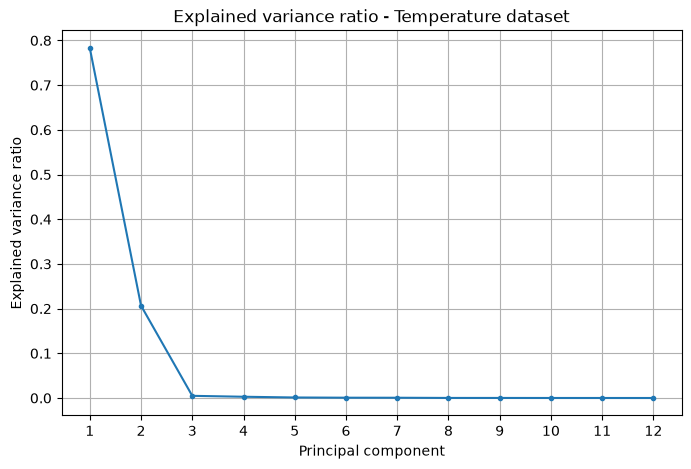

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(explained_temp) + 1), explained_temp, marker="o", markersize=3)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance ratio - Temperature dataset")
plt.xticks(np.arange(1, len(explained_temp) + 1))
plt.grid()

plt.show()

The first two principal components explain approximately 98.97% of the total variance. \
Therefore, projecting the temperature data from 12 dimensions to only 2 dimensions results in very little loss of variance. \
This confirms the strong redundancy observed in the covariance matrix : monthly temperatures are highly correlated.

This makes p=2 particularly appropriate for visualization in this dataset.

In [ ]:
pca_digits = PCA(n_components=None)
pca_digits.fit(x2)

explained_digits = pca_digits.explained_variance_ratio_

print("\nVariance explained by the first 2 components:")
print(explained_digits[:2].sum())


Variance explained by the first 2 components:
0.2695057794431237


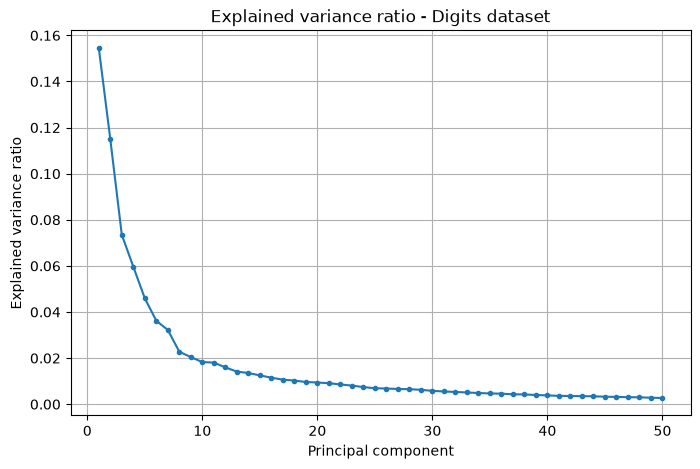

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, 51), explained_digits[:50], marker="o", markersize=3)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained variance ratio - Digits dataset")
plt.grid()

plt.show()

The first two principal components explain only approximately 26.95% of the total variance. \
Therefore, a 2D PCA projection discards a large fraction of the variability present in the original 784-dimensional images. \
The digits dataset has a much more complex structure than the temperature dataset.

Therefore, PCA in two dimensions should mainly be interpreted as a visualization tool for the digits dataset rather than as a nearly lossless representation.

#### Q3.

In [ ]:
xp_temp = pca_temp.transform(x1)
xp_temp_2d = xp_temp[:, :2]

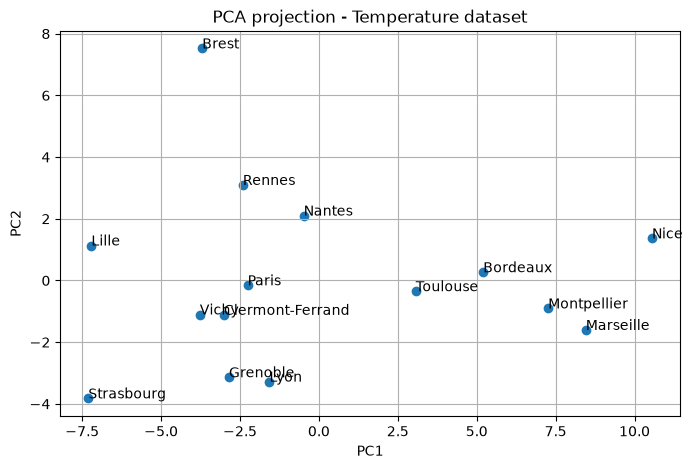

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(xp_temp_2d[:, 0], xp_temp_2d[:, 1])

for i, city in enumerate(villes):
    plt.text(xp_temp_2d[i, 0], xp_temp_2d[i, 1], city)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection - Temperature dataset")
plt.grid()

plt.show()

The 2D PCA projection shows a clear organization of the cities according to their temperature profiles. \
This suggests that PC1 mainly captures differences in overall temperature level, while PC2 appears to capture differences in seasonal/climatic profile. \
The projection is consistent with geographical/climatic similarities, even though latitude and longitude were not used by PCA.

Since the first two components preserve about 98.97% of the total variance, the 2D representation retains almost all of the main structure of the temperature dataset.

In [ ]:
xp_digits = pca_digits.transform(x2)
xp_digits_2d = xp_digits[:, :2]

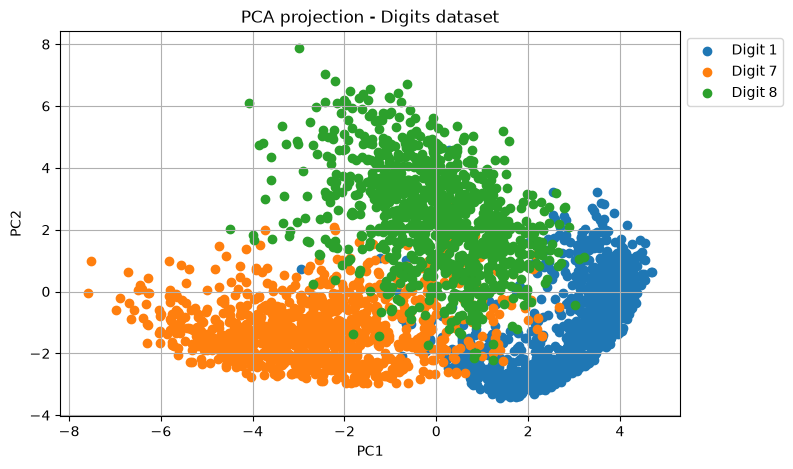

In [ ]:
plt.figure(figsize=(8, 5))

for digit in np.unique(y2):
    mask = (y2.ravel() == digit)

    plt.scatter(xp_digits_2d[mask, 0], xp_digits_2d[mask, 1], label=f"Digit {digit}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection - Digits dataset")
plt.grid()
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

plt.show()

The three digit classes show a clear structure in the 2D PCA space.

However, there is significant overlap between the three classes \
The classes are therefore not perfectly separable using only the first two principal components. \
This is consistent with the fact that the first two components preserve only about 26.95% of the total variance.

#### Q4.

In [ ]:
pc1_temp = pca_temp.components_[0]
pc2_temp = pca_temp.components_[1]

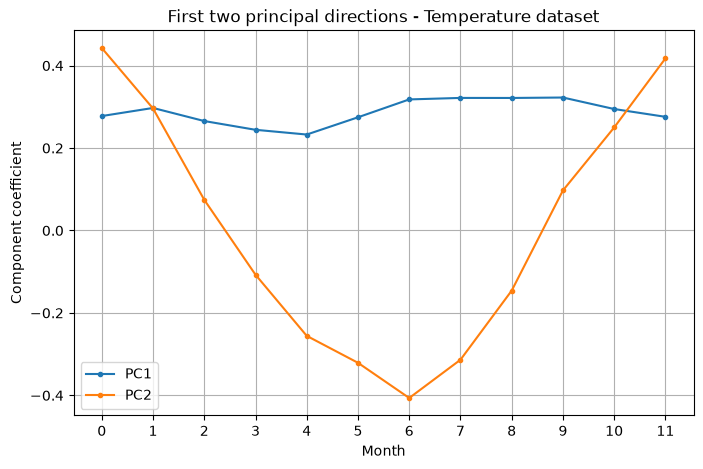

In [ ]:
months = np.arange(12)

plt.figure(figsize=(8, 5))

plt.plot(months, pc1_temp, marker="o", markersize=3, label="PC1")
plt.plot(months, pc2_temp, marker="o", markersize=3, label="PC2")

plt.xlabel("Month")
plt.ylabel("Component coefficient")
plt.title("First two principal directions - Temperature dataset")
plt.xticks(months)
plt.grid()
plt.legend()

plt.show()

The coefficients of PC1 are positive and relatively similar for all months. \
PC1 mainly represents the overall temperature level of a city. \
A larger PC1 coordinate corresponds to a generally warmer annual profile, moving in the opposite direction corresponds to a colder profile.

PC2 has positive coefficients during winter and negative coefficients during spring and summer. \
Therefore, PC2 mainly captures the seasonal amplitude of the temperature profile. \
Moving in one direction along PC2 makes winters milder and summers cooler. \
Moving in the opposite direction makes winters colder and summers warmer.

In [ ]:
pc1_digits = pca_digits.components_[0]
pc2_digits = pca_digits.components_[1]

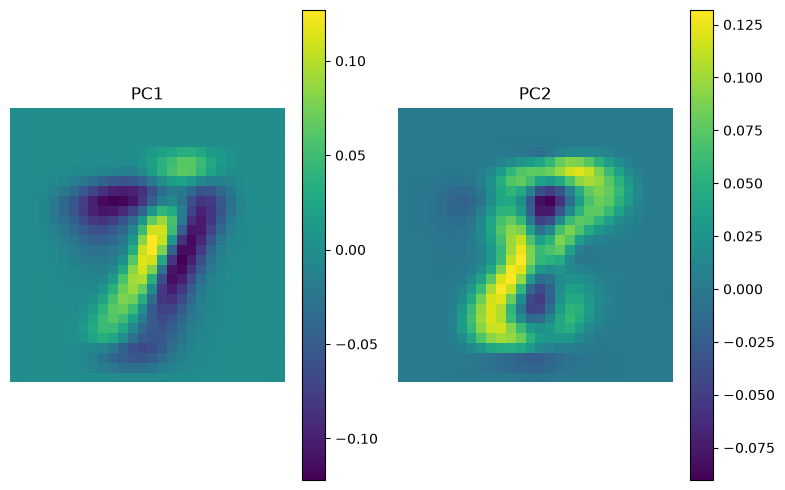

In [ ]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
plt.imshow(pc1_digits.reshape(28, 28))
plt.title("PC1")
plt.colorbar()
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pc2_digits.reshape(28, 28))
plt.title("PC2")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

PC1 contains positive and negative pixel regions, meaning that moving along this direction simultaneously increases some pixel intensities and decreases others. \
Therefore, PC1 appears to capture an important variation that separates 1-like shapes from 7-like shapes. \
Positive movement along PC1 tends to emphasize stroke patterns associated with digit 1, while negative movement tends toward patterns more typical of digit 7.

PC2 contains a structure resembling the variations associated with the loops of digit 8. \
Therefore, PC2 seems to capture variations that distinguish 8-like shapes from the other digits.

#### Q5.

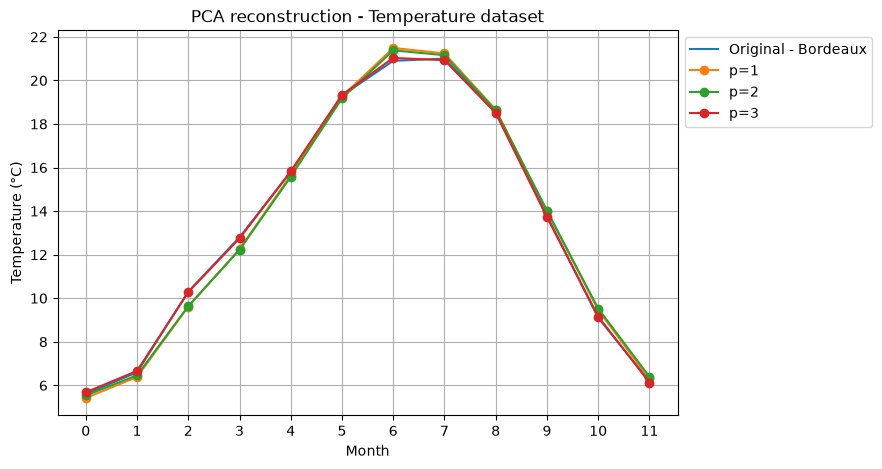

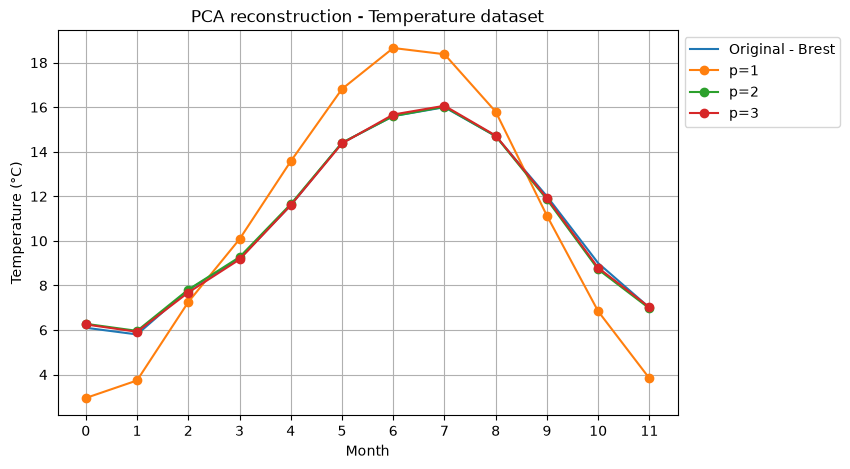

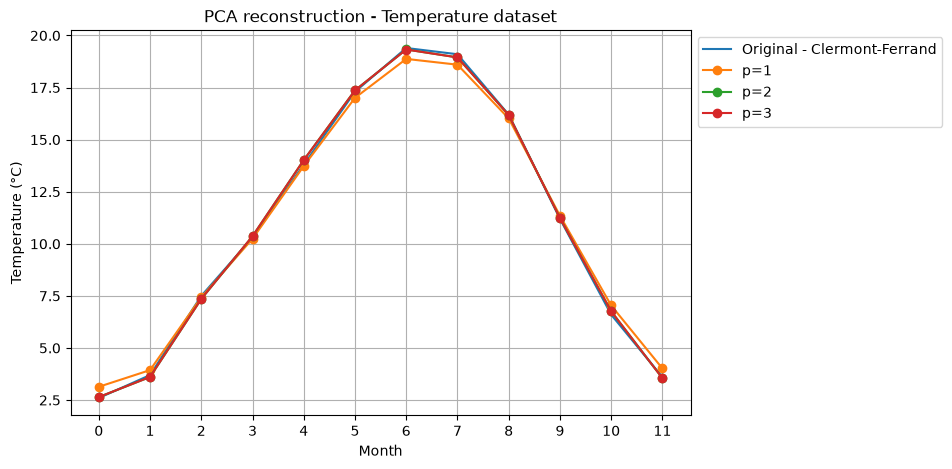

In [ ]:
p_values_temp = [1, 2, 3]

months = np.arange(12)

for city_idx in [0, 1, 2]:

    plt.figure(figsize=(8, 5))

    # Original sample
    plt.plot(months, x1[city_idx], label=f"Original - {villes[city_idx]}")

    for p in p_values_temp:
        model = PCA(n_components=p)

        xp = model.fit_transform(x1)
        x_reconstructed = model.inverse_transform(xp)

        plt.plot(months, x_reconstructed[city_idx], marker="o", label=f"p={p}")

    plt.xlabel("Month")
    plt.ylabel("Temperature (°C)")
    plt.title("PCA reconstruction - Temperature dataset")
    plt.xticks(months)
    plt.grid()
    plt.legend(bbox_to_anchor=(1, 1), loc="upper left")

    plt.show()

The reconstruction quality improves as the number of retained principal components p increases. \
For cities such as Bordeaux and Clermont-Ferrand, even p=1 already gives a relatively good approximation of the annual temperature profile.

Brest is a particularly interesting case : the reconstruction with p=1 is much worse \
Adding the second principal component greatly improves Brest's reconstruction because PC2 captures differences in seasonal amplitude.

With p=2, the reconstructions are already almost indistinguishable from the original profiles. \
This is consistent with the first two principal components explaining about 98.97% of the total variance.

Increasing to p=3 produces only a small additional improvement.

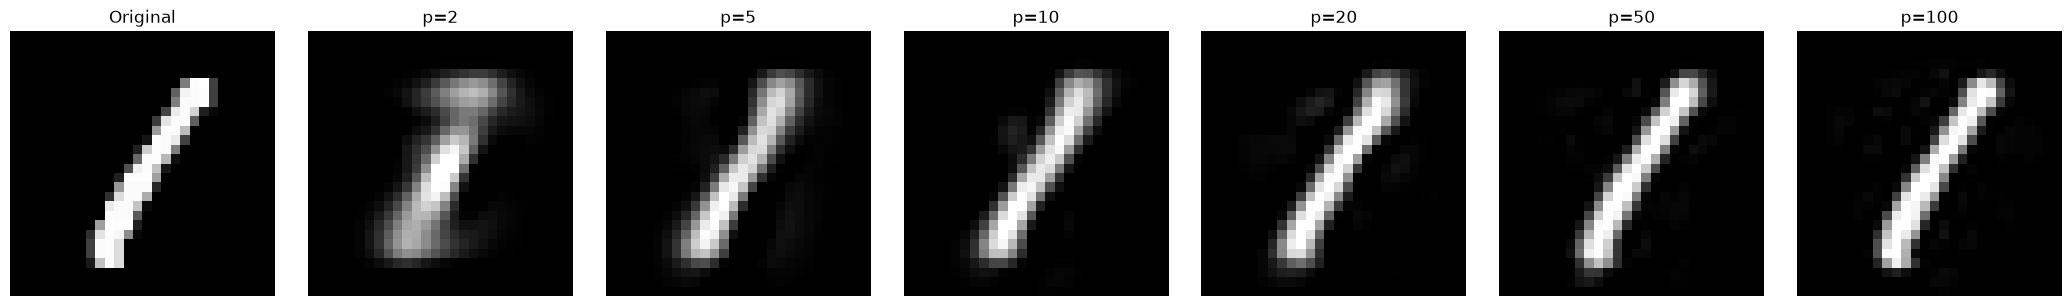

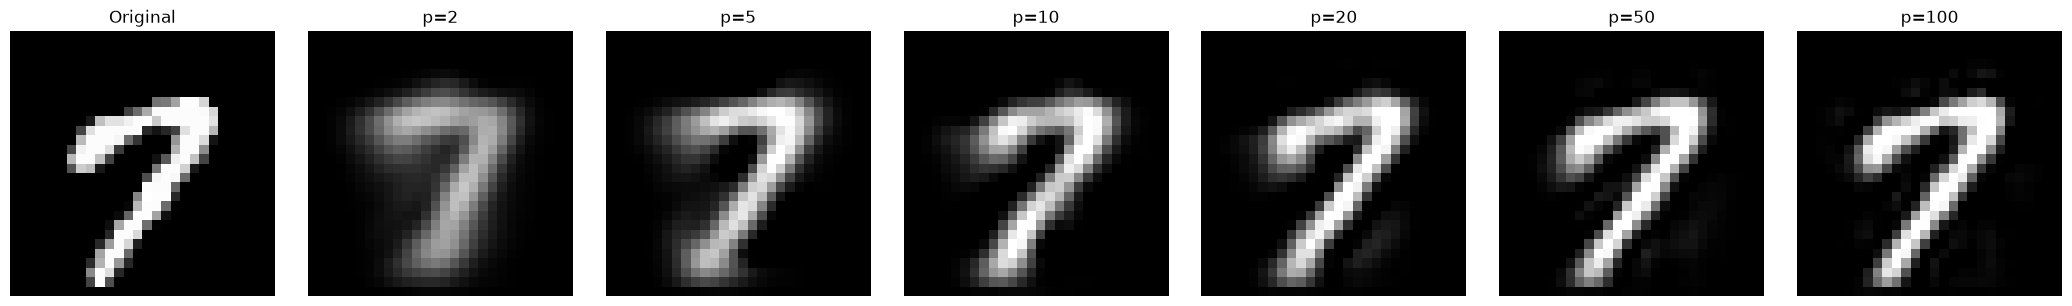

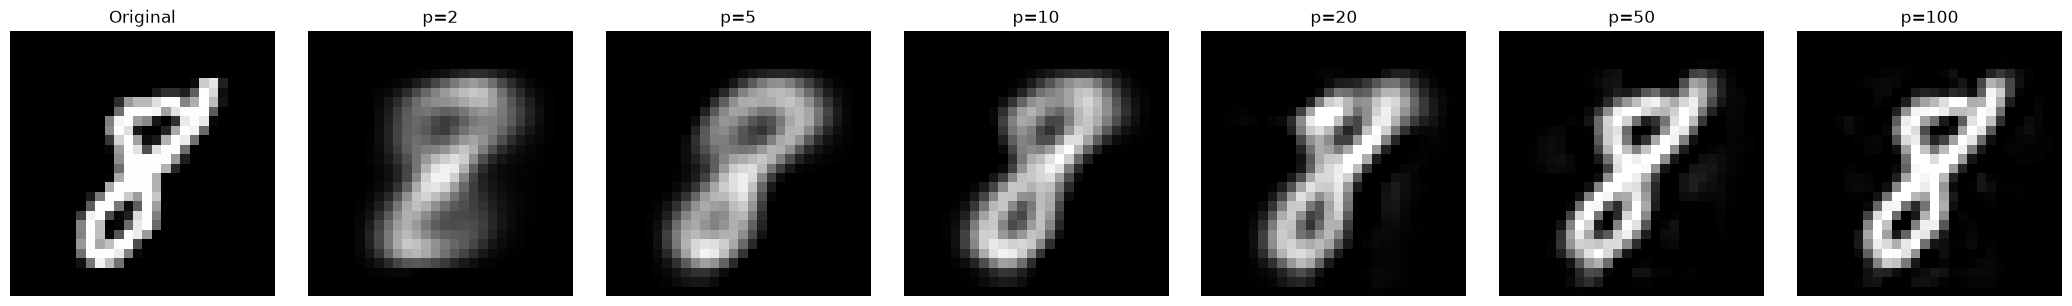

In [ ]:
p_values_digits = [2, 5, 10, 20, 50, 100]

for sample_idx in [0, 1000, 2000]:
    plt.figure(figsize=(3 * (len(p_values_digits) + 1), 3))

    # Original
    plt.subplot(1, len(p_values_digits) + 1, 1)
    plt.imshow(x2[sample_idx].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    plt.title("Original")
    plt.axis("off")

    for j, p in enumerate(p_values_digits):
        model = PCA(n_components=p)

        xp = model.fit_transform(x2)
        x_reconstructed = model.inverse_transform(xp)

        plt.subplot(1, len(p_values_digits) + 1, j + 2)
        plt.imshow(x_reconstructed[sample_idx].reshape(28, 28), cmap="gray", vmin=0, vmax=1)

        plt.title(f"p={p}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

With only p=2, the reconstructed digits are strongly blurred and many individual handwriting details are lost. \
However, the general digit class is often still recognizable.

Increasing p progressively recovers finer details such as stroke orientation, thickness, curvature and local shape. \
The improvement is particularly visible between p=2, p=5, p=10 and p=20.\
With p=50 or p=100, the reconstructed images become visually close to the original samples.

Therefore, the digits require significantly more dimensions than the temperature dataset for accurate reconstruction. \
This is consistent with the fact that the first two principal components explain only about 26.95% of the total variance.

#### Q6. (Bonus)

In [ ]:
nmf_temp = NMF(n_components=2, random_state=0)

W_temp = nmf_temp.fit_transform(x1)
H_temp = nmf_temp.components_

print("W shape:", W_temp.shape)
print("H shape:", H_temp.shape)

W shape: (15, 2)
H shape: (2, 12)


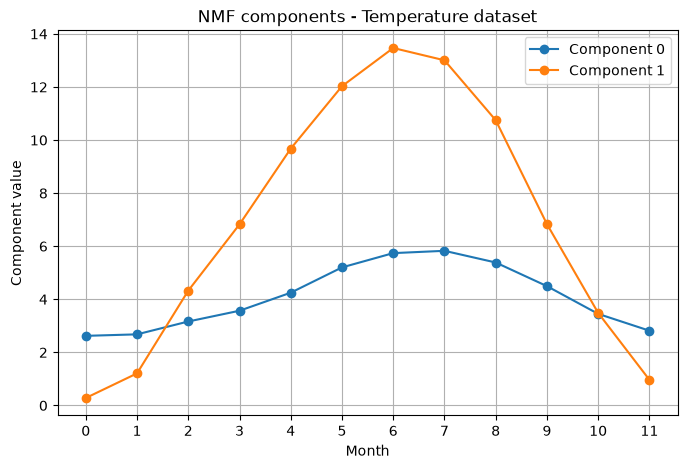

In [ ]:
plt.figure(figsize=(8, 5))
months = np.arange(12)

for k in range(2):
    plt.plot(months, H_temp[k], marker="o", label=f"Component {k}")

plt.xlabel("Month")
plt.ylabel("Component value")
plt.title("NMF components - Temperature dataset")
plt.xticks(np.arange(12))
plt.grid()
plt.legend()

plt.show()

One component captures a relatively constant baseline temperature while the other captures a strong seasonal variation. \
Each city is represented as a positive combination of these components.

In [ ]:
nmf_digits = NMF(n_components=3, random_state=0)

W_digits = nmf_digits.fit_transform(x2)
H_digits = nmf_digits.components_

print("W shape:", W_digits.shape)
print("H shape:", H_digits.shape)

W shape: (3000, 3)
H shape: (3, 784)


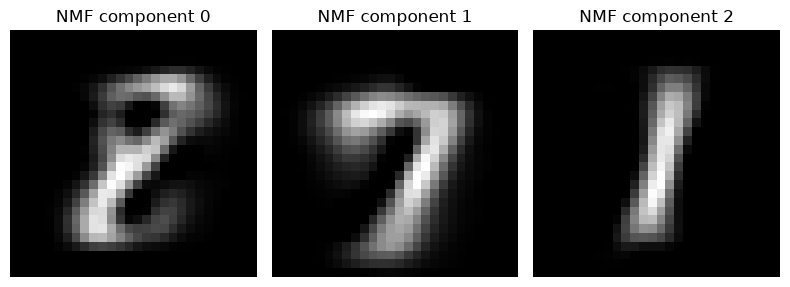

In [ ]:
plt.figure(figsize=(8, 5))

for k in range(3):
    plt.subplot(1, 3, k + 1)

    plt.imshow(H_digits[k].reshape(28, 28),cmap="gray")

    plt.title(f"NMF component {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

The components resemble meaningful digit structures, approximately associated with 8, 7, and 1. \
Each pixel is represented as a positive combination of these components.

### 4.2 Manifold Learning : TSNE

#### Q1.

In [ ]:
tsne_temp = TSNE(n_components=2, perplexity=5, random_state=0) # perplexity must be less than n_samples
xtsne_temp = tsne_temp.fit_transform(x1)

In [ ]:
tsne_digits = TSNE(n_components=2, perplexity=30, random_state=0)
xtsne_digits = tsne_digits.fit_transform(x2)

#### Q2.

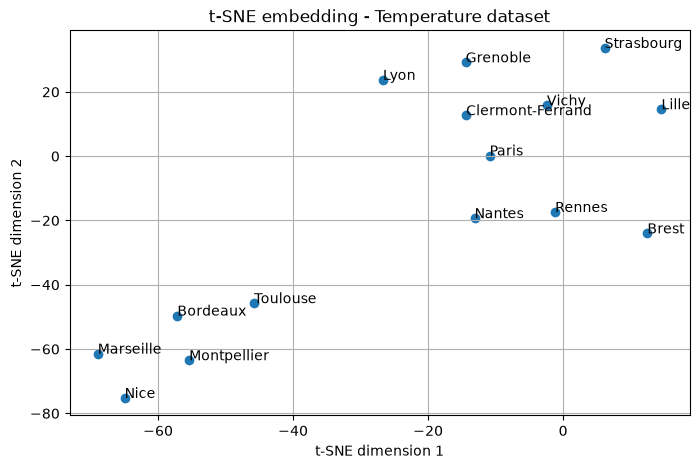

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(xtsne_temp[:, 0], xtsne_temp[:, 1])

for i, city in enumerate(villes):
    plt.text(xtsne_temp[i, 0], xtsne_temp[i, 1], city)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("t-SNE embedding - Temperature dataset")
plt.grid()

plt.show()

The t-SNE embedding groups cities with similar temperature profiles \
It recovers a meaningful climatic structure that is also partly correlated with geographical location.

The result is broadly consistent with the groups previously observed with K-means and PCA.

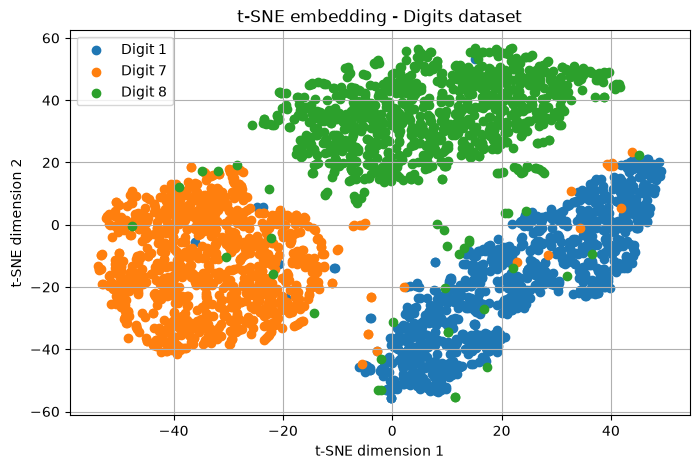

In [ ]:
plt.figure(figsize=(8, 5))

for digit in np.unique(y2):
    mask = y2.ravel() == digit

    plt.scatter(xtsne_digits[mask, 0], xtsne_digits[mask, 1], label=f"Digit {digit}")

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("t-SNE embedding - Digits dataset")
plt.legend()
plt.grid()

plt.show()

The three classes are much more clearly separated than in the 2D PCA projection. \
Only a relatively small number of samples overlap with another class or appear as isolated points. \
Therefore, the local neighborhood structure of the original pixel space is strongly correlated with the true digit classes.

This is possible because t-SNE is nonlinear and is not restricted to projecting the data onto a linear 2D subspace.

#### Q3.

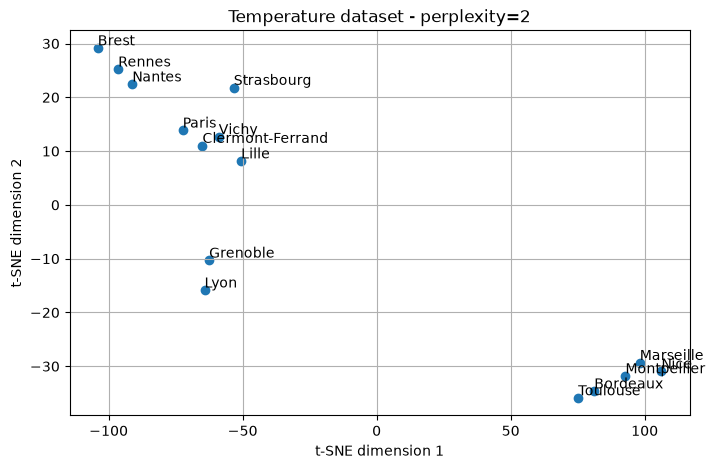

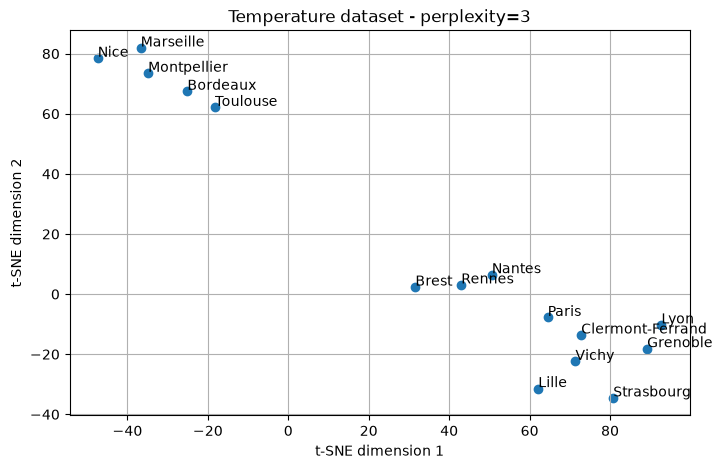

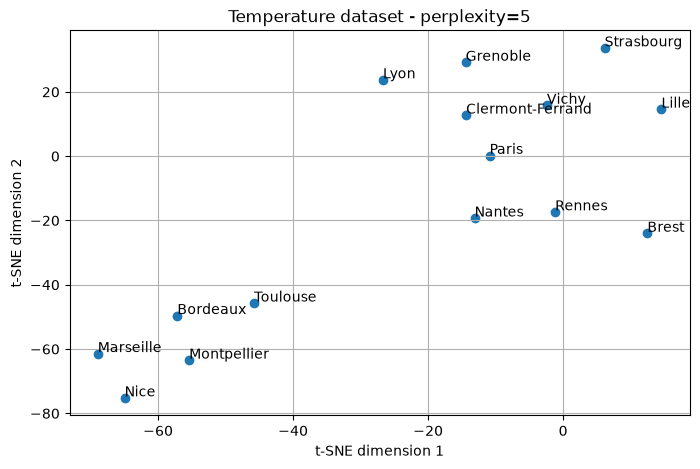

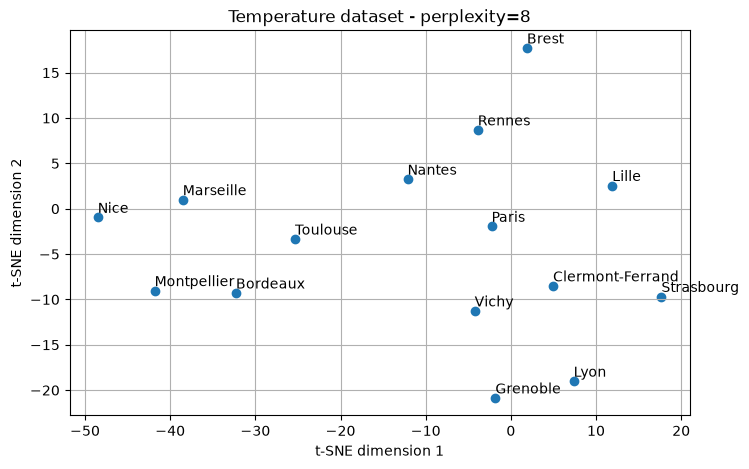

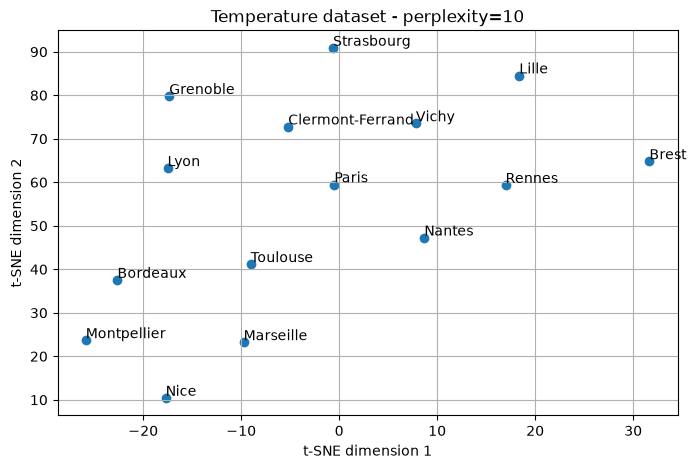

In [ ]:
perplexities_temp = [2, 3, 5, 8, 10]

for perp in perplexities_temp:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=0)

    embedding = tsne.fit_transform(x1)

    plt.figure(figsize=(8, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1])

    for i, city in enumerate(villes):
        plt.text(embedding[i, 0], embedding[i, 1] + 0.5, city)

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title(f"Temperature dataset - perplexity={perp}")
    plt.grid()

    plt.show()

The t-SNE embedding is quite sensitive to the perplexity because the dataset contains only 15 samples. \
With very small perplexities, t-SNE focuses on extremely local neighborhoods. \
However, with such small perplexities, the separation between groups may be exaggerated.

Around perplexity 5, the embedding still preserves meaningful climatic neighborhoods while avoiding some of the strongest fragmentation.

For larger perplexities such as 8 or 10, the representation becomes more global and less strongly clustered.

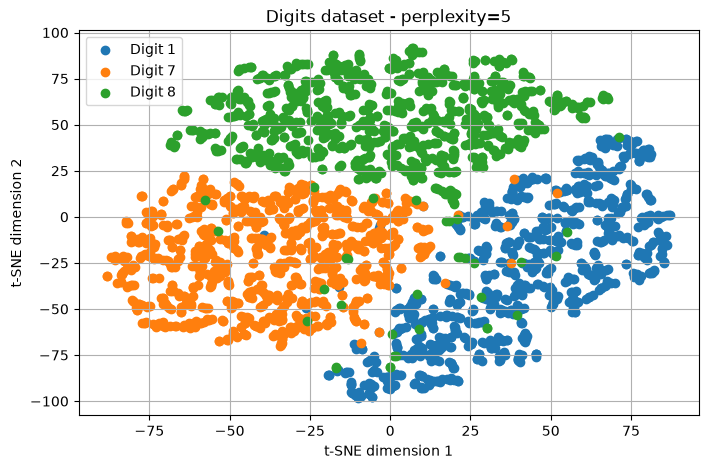

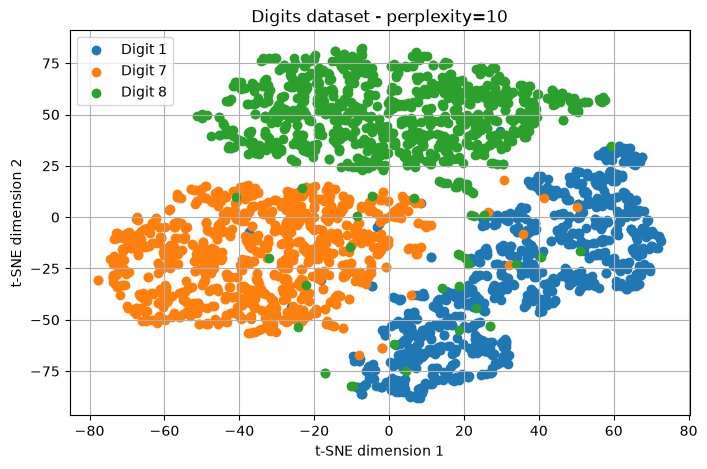

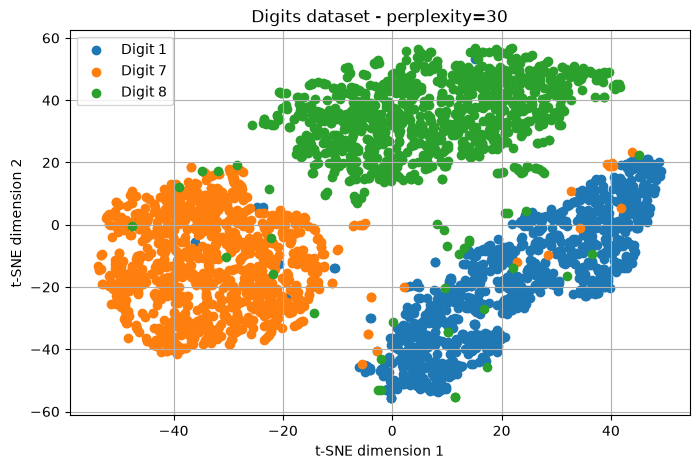

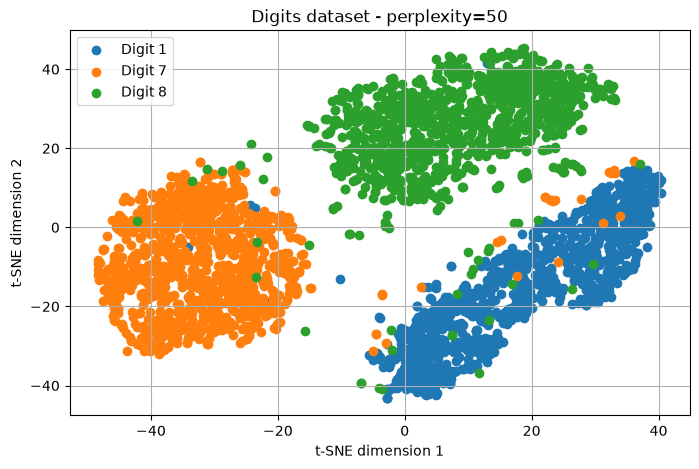

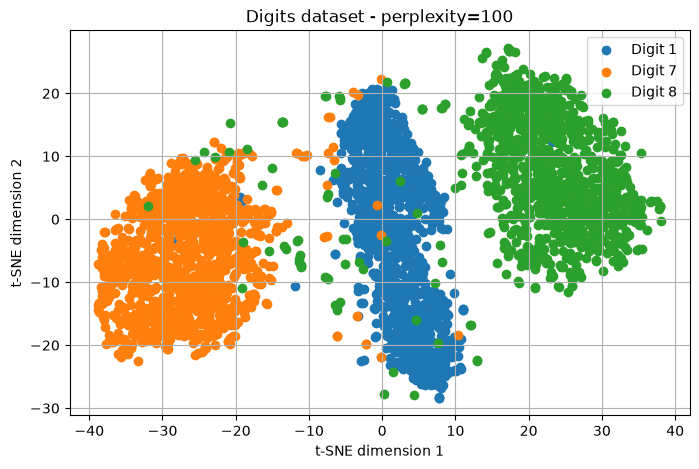

In [ ]:
perplexities_digits = [5, 10, 30, 50, 100]

for perp in perplexities_digits:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=0)

    embedding = tsne.fit_transform(x2)

    plt.figure(figsize=(8, 5))

    for digit in np.unique(y2):
        mask = y2.ravel() == digit

        plt.scatter(embedding[mask, 0], embedding[mask, 1], label=f"Digit {digit}")

    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.title(f"Digits dataset - perplexity={perp}")
    plt.legend()
    plt.grid()

    plt.show()

The three classes remain clearly visible over a wide range of perplexity values.

With small perplexities such as 5 or 10, the embedding emphasizes very local structure and the classes have more elongated or fragmented shapes.

With intermediate perplexities such as 30 or 50, the three classes form coherent and well-separated regions.

With perplexity 100, the embedding becomes more globally organized and the three classes are still clearly separated, although their global shapes can change.

The main neighborhood structure is relatively stable.

## Personal discussion about the session

The most difficult part for me was understanding why one method could perform better than another for the same objective. \
For example, when comparing K-means and GMM for clustering, it was necessary to go back to the assumptions of each model and identify which assumptions were too restrictive for the data.

The most difficult part to implement and manipulate was working with image data and with linear algebra objects.

I learned more about the different uses of GMMs, not only for clustering but also for density estimation, outlier detection and data generation. \
I also improved my understanding of how to interpret PCA principal directions and what moving along these directions means in the original feature space.

The practical session also made some concepts from the course clearer, especially the different components of a GMM, such as the mixture weights, component means and covariance matrices.

If I had to do the practical session again without help, I would systematically start by visualizing the data before applying clustering or density estimation methods. \
This makes it much easier to interpret the behavior and results of the models afterwards.

During previous internships, I worked with very high-dimensional data, dimensionality reduction and visualization tools were particularly important. \